In [1]:
# # remember to resteart kernell
# ! pip install -e ../../wazeasy
# ! pip install pandas "dask[complete]" pyarrow plotly
# ! pip install --upgrade s3fs
# ! pip install geopandas
# ! pip install seaborn
# ! pip install folium matplotlib mapclassifys
# ! pip install h3
# ! pip install dask-geopandas
# ! pip install folium matplotlib mapclassify

In [2]:
import os
os.environ['AWS_CA_BUNDLE'] = '/Users/mtadeo/Documents/gitrepo/cacert_new.pem'
os.environ['REQUESTS_CA_BUNDLE'] = '/Users/mtadeo/Documents/gitrepo/cacert_new.pem'

In [3]:
import pandas as pd
import dask.dataframe as dd
from wazeasy import utils, plots, reports
import geopandas as gpd
from shapely import Polygon
from h3 import LatLngPoly
import yaml

In [4]:
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

In [5]:
storage_options = {'profile': 'ddp_dec',
    'client_kwargs': {
        'verify': '/Users/mtadeo/Documents/gitrepo/cacert_new.pem'
        }}

file_list = [
    's3://wbg-waze/bq/IQ/682baghdad/jams/IQ_682baghdad_jams.000000000000.parquet',
    's3://wbg-waze/bq/IQ/682baghdad/jams/IQ_682baghdad_jams.000000000001.parquet',
    's3://wbg-waze/bq/IQ/682baghdad/jams/IQ_682baghdad_jams.000000000002.parquet',
    's3://wbg-waze/bq/IQ/682baghdad/jams/IQ_682baghdad_jams.000000000003.parquet',
    's3://wbg-waze/bq/IQ/682baghdad/jams/IQ_682baghdad_jams.000000000004.parquet',
    's3://wbg-waze/bq/IQ/682baghdad/jams/IQ_682baghdad_jams.000000000005.parquet',
    's3://wbg-waze/bq/IQ/682baghdad/jams/IQ_682baghdad_jams.000000000006.parquet',
    's3://wbg-waze/bq/IQ/682baghdad/jams/IQ_682baghdad_jams.000000000007.parquet',
    's3://wbg-waze/bq/IQ/682baghdad/jams/IQ_682baghdad_jams.000000000008.parquet',
    's3://wbg-waze/bq/IQ/682baghdad/jams/IQ_682baghdad_jams.000000000009.parquet'
]
ddf = dd.read_parquet(file_list, storage_options = storage_options, engine = 'pyarrow')

# path = 's3://wbg-waze/bq/IQ/682baghdad/jams/'
# df = pd.read_parquet(path, storage_options=storage_options)

In [6]:
ddf = ddf.compute()

In [7]:
timezone = config['Baghdad']['timezone']['timezone_name']
geographies = config['Baghdad']['geographies']

In [8]:
dict_geogs = {geog: gpd.read_file(geog_data['path']) for geog, geog_data in geographies.items()}

In [9]:
utils.handle_time(ddf, timezone)
ddf = utils.remove_level5(ddf)

In [10]:
ddf = utils.assign_geography_to_jams(ddf, dict_geogs)

alt.Chart(...)

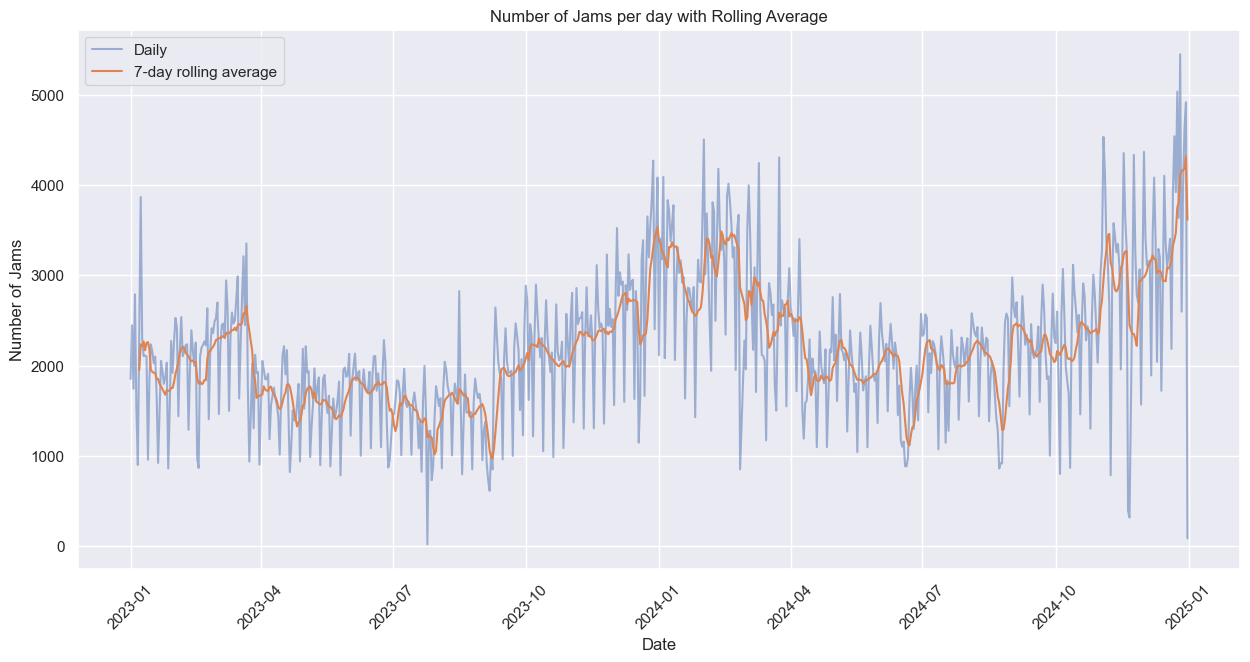

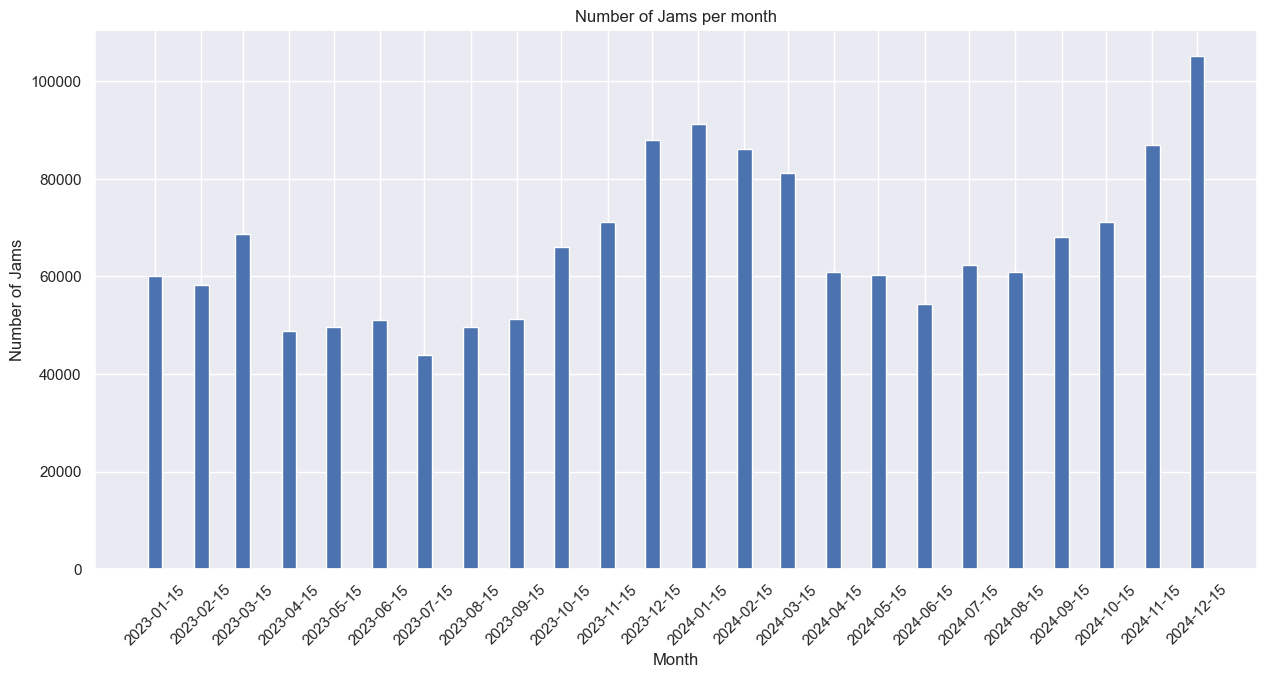

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

In [11]:
reports.run_basic_report(ddf)

In [12]:
reports.run_geog_report(ddf, geographies, start_date = None, end_date = None)

Running report for Administrative Level 1


alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

Running report for Administrative Level 2


alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

Running report for Hexagons Level 7


# Accidents